# Ground state of the 2D Fermi-Hubbard model benchmark

This notebook benchmarks quantum phase estimation (QPE) for the ground state of the
**Fermi-Hubbard model on a two-dimensional square lattice**, and estimates the fault-tolerant
resources required to run it.

$$
H = -T\sum_{\langle i,j\rangle,\;\sigma\in\{\uparrow,\downarrow\}} \left(c^{\dagger}_{i\sigma}c_{j\sigma} + \text{h.c.}\right)
  \; + \; U\sum_{i} n_{i\uparrow}\,n_{i\downarrow},
\qquad n_{i\sigma}=c^{\dagger}_{i\sigma}c_{i\sigma}
$$

Here $c^{\dagger}_{i\sigma}$ and $c_{j\sigma}$ are the fermionic creation and annihilation operators on lattice sites $i,j$, and $n_{i\sigma}$ is the on-site occupation with spin $\sigma$.

The two algorithm knobs -- the width `num_bits` of the QPE phase register and the number `num_divisions`
of Trotter steps -- are *not* hand-tuned. They are derived for every lattice from the target energy
precision and the Hamiltonian itself, see [Sizing the QPE and Trotter parameters](#sizing). The resulting Q# circuit is handed
straight to `qdk.qre`, so no hand-written logical-count formula sits between the algorithm and the estimate.

**Benchmark specification**

| Quantity | Value |
|---|---|
| Lattice | 2D square, periodic in both directions, $N=L^{2}$ sites |
| Parameters | $U/T = 1/8$, $f = 0.875$, i.e. $2fN$ electrons |
| Initial state | Occupation-number reference determinant |
| Target | Ground-state energy to $0.0051\,T$ per site |
| Hardware model | Majorana qubits, measurement error rate $10^{-5}$ |

**References**

- Campbell, Earl T. "Early fault-tolerant simulations of the Hubbard model." *Quantum Science & Technology* **7**.1 (2022): 015007. [arXiv:2012.09238](https://arxiv.org/abs/2012.09238)
- Bärtschi, Andreas, et al. "Potential applications of quantum computing at Los Alamos National Laboratory." (2024), Chapter 5, Application 1. [arXiv:2406.06625](https://arxiv.org/abs/2406.06625)
- Childs, Andrew M., et al. "Theory of Trotter error with commutator scaling." *Physical Review X* **11**.1 (2021): 011020. [arXiv:1912.08854](https://arxiv.org/abs/1912.08854)
- Nielsen, Michael A., and Isaac L. Chuang. *Quantum Computation and Quantum Information*, Sec. 5.2.1.

**Requirements**

```bash
pip install 'qdk-chemistry[jupyter,qre]'
```

In [1]:
from qdk_chemistry.algorithms import create
from qdk_chemistry.data import (
    AlgorithmRef,
    Circuit,
    LatticeGraph,
    MajoranaMapping,
)
from qdk_chemistry.data.circuit import QsharpFactoryData
from qdk_chemistry.utils import Logger
from qdk_chemistry.utils.model_hamiltonians import create_hubbard_hamiltonian
from qdk_chemistry.utils.qsharp import QSHARP_UTILS

Logger.set_global_level(Logger.LogLevel.off)

HOPPING_T = 1.0                                          # T > 0, energies are quoted in units of T
U_OVER_T = 1.0 / 8.0                                     # on-site repulsion / hopping
COULOMB_U = U_OVER_T * HOPPING_T
FILLING = 0.875                                          # 2 * FILLING * N electrons in total
LATTICE_SIZES = [2, 3, 4, 5, 6]
TARGET_PRECISION_PER_SITE = 0.0051   # energy accuracy per lattice site, in units of T


def target_precision(size: int) -> float:
    """Absolute ground-state energy accuracy required of an L x L lattice."""
    return TARGET_PRECISION_PER_SITE * size * size


print(f"Hubbard model: U/T = {U_OVER_T:g}  (T = {HOPPING_T:g}, U = {COULOMB_U:g}) Filling factor f = {FILLING:g}")
print(f"Lattice sizes L = {LATTICE_SIZES}")

Hubbard model: U/T = 0.125  (T = 1, U = 0.125) Filling factor f = 0.875
Lattice sizes L = [2, 3, 4, 5, 6]


## The lattice and the qubit Hamiltonian

`LatticeGraph.square` builds the $L\times L$ lattice and `create_hubbard_hamiltonian` turns it into a
fermionic Hamiltonian. The Jordan-Wigner mapping then produces the qubit Hamiltonian on $2N$ qubits
(one per spin-orbital).

The benchmark asks for $2fN$ electrons at $f = 0.875$, which is not an integer for every $N$. We round to the
nearest electron count and split it as evenly as possible between the two spin sectors, so $|S_z| \le 1/2$.

The mapping lays the spin-orbitals out in blocks: qubits $0 \dots N-1$ carry the spin-up sites and qubits
$N \dots 2N-1$ the spin-down sites, which is why the on-site $U$ term shows up as a $Z_i Z_{i+N}$ coupling.

In [2]:
def qubit_operator(size: int):
    """Jordan-Wigner qubit Hamiltonian of the periodic size x size Hubbard lattice."""
    num_sites = size * size
    lattice = LatticeGraph.square(size, size, periodic_x=True, periodic_y=True)
    hamiltonian = create_hubbard_hamiltonian(
        lattice, epsilon=0.0, t=HOPPING_T, U=COULOMB_U
    )
    operator = create("qubit_mapper").run(
        hamiltonian, mapping=MajoranaMapping.jordan_wigner(2 * num_sites)
    )
    return operator


def num_electrons(size: int) -> int:
    """Electron count nearest to the requested filling 2 * f * N."""
    return round(2 * FILLING * size * size)


example = qubit_operator(2)
print(f"2x2 lattice: {example.num_qubits} qubits, {len(example.pauli_strings)} Pauli terms, "
      f"{num_electrons(2)} electrons, lambda = {example.schatten_norm:g}")

2x2 lattice: 8 qubits, 29 Pauli terms, 7 electrons, lambda = 16.5


<a id="sizing"></a>

## Sizing the QPE and Trotter parameters

Both algorithm knobs follow from one input, the target precision $\epsilon(L)$, and one property of the
qubit Hamiltonian $H = \sum_j c_j P_j$: its coefficient 1-norm

$$
\lambda = \sum_j |c_j|,
$$

returned by `QubitOperator.schatten_norm`.

**Evolution time.** Every eigenvalue of $H$ lies in $[-\lambda, \lambda]$, so

$$
t_0 = \frac{\pi}{\lambda}
$$

maps the spectrum of $H t_0$ into $[-\pi, \pi]$ and the QPE phase into $[-\tfrac{1}{2}, \tfrac{1}{2})$. The
whole phase register is used and no eigenvalue aliases.

**Error budget.** The target precision is split between the two independent error sources,
$\epsilon = \epsilon_{\mathrm{QPE}} + \epsilon_{\mathrm{Trotter}}$.

**Phase register width.** An $m$-bit register resolves the phase to $2^{-m}$, hence the energy to
$2\lambda / 2^{m}$. Resolving $\epsilon_{\mathrm{QPE}}$ therefore costs
$\lceil \log_2 (2\lambda/\epsilon_{\mathrm{QPE}}) \rceil$ bits, and reading those leading bits correctly with
probability $1 - \delta$ costs $\lceil \log_2 (2 + 1/2\delta) \rceil$ additional guard bits (Nielsen & Chuang,
Sec. 5.2.1):

$$
m = \left\lceil \log_2 \frac{2\lambda}{\epsilon_{\mathrm{QPE}}} \right\rceil
  + \left\lceil \log_2 \left( 2 + \frac{1}{2\delta} \right) \right\rceil .
$$

**Trotter steps.** QPE applies powers of a *single* fixed unitary $U = S_2(t_0)$. A product formula realizes
$U$ exactly as $e^{-i H_{\mathrm{eff}} t_0}$ for some effective Hamiltonian, so the readout is an exact
eigenvalue of $H_{\mathrm{eff}}$ and the Trotter error does not accumulate over the $2^{m}-1$ repetitions --
it shows up once, as the bias
$\lVert H_{\mathrm{eff}} - H \rVert \le \lVert S_2(t_0) - e^{-iHt_0} \rVert / t_0$. Holding that bias below
$\epsilon_{\mathrm{Trotter}}$ means the product formula must be accurate to

$$
\delta_{\mathrm{Trotter}} = \epsilon_{\mathrm{Trotter}} \, t_0
$$

in spectral norm. The step count that achieves it comes from the order-2 **commutator bound** of Childs
*et al.* (Prop. 10), evaluated by `trotter_steps_commutator`:

$$
r = \left\lceil \sqrt{\frac{\alpha_2}{12}} \; \frac{t_0^{3/2}}{\sqrt{\delta_{\mathrm{Trotter}}}} \right\rceil,
\qquad
\alpha_2 = \sum_{k>j,\,l>j} \bigl\lVert [c_l P_l, [c_k P_k, c_j P_j]] \bigr\rVert
         + \tfrac{1}{2} \sum_{k>j} \bigl\lVert [c_j P_j, [c_j P_j, c_k P_k]] \bigr\rVert .
$$

The commutator bound is far tighter than the triangle-inequality (`"naive"`) bound because most Pauli pairs
commute, but evaluating $\alpha_2$ costs $O(n_{\mathrm{terms}}^{3})$ -- that, not the resource estimation, is
what caps the lattice sizes swept in this notebook.

In [3]:
import math
from dataclasses import dataclass

from qdk_chemistry.algorithms.hamiltonian_unitary_builder.time_evolution.trotter_error import (
    trotter_steps_commutator,
)

TROTTER_ORDER = 2                    # Suzuki-Trotter product-formula order
TROTTER_ERROR_FRACTION = 0.5         # share of the precision budget spent on Trotter error
QPE_FAILURE_PROBABILITY = 0.1        # 1 - confidence that the readout meets the target precision


@dataclass(frozen=True)
class QpeParameters:
    """Algorithm parameters derived from a target precision."""

    one_norm: float        # lambda
    evolution_time: float  # t_0
    num_bits: int          # m
    num_divisions: int     # r


def qpe_parameters(operator, precision: float) -> QpeParameters:
    """Derive the QPE register width and Trotter step count for a target precision."""
    one_norm = operator.schatten_norm
    evolution_time = math.pi / one_norm

    trotter_budget = TROTTER_ERROR_FRACTION * precision
    readout_budget = precision - trotter_budget

    resolution_bits = math.ceil(math.log2(2 * one_norm / readout_budget))
    guard_bits = math.ceil(math.log2(2 + 1 / (2 * QPE_FAILURE_PROBABILITY)))

    num_divisions = trotter_steps_commutator(
        operator,
        evolution_time,
        trotter_budget * evolution_time,   # spectral-norm accuracy required of S_2(t_0)
        order=TROTTER_ORDER,
    )
    return QpeParameters(one_norm, evolution_time, resolution_bits + guard_bits, num_divisions)


parameters = qpe_parameters(example, target_precision(2))
print(f"2x2 lattice, epsilon = {target_precision(2):g}: {parameters}")

2x2 lattice, epsilon = 0.0204: QpeParameters(one_norm=16.5, evolution_time=0.19039955476301776, num_bits=15, num_divisions=8)


## Reference state and QPE circuit

The benchmark calls for a Hartree-Fock (Fermi-sea) reference. In the site basis that the Jordan-Wigner
mapping works in, the Fermi sea is a *momentum*-space determinant, so preparing it exactly needs a
Givens-rotation network of $O(N^{2})$ two-qubit gates. We use the site-basis occupation-number determinant
with the same particle number and $S_z = 0$ instead, which is a single layer of $X$ gates. The two choices
differ in *overlap* with the ground state -- which sets how many times QPE has to be repeated -- but barely
in *cost*: $O(N^{2}) \approx 10^{3}$ gates against the $\sim 10^{7}$ rotations inside the QPE ladder.

`qdk_standard` then assembles the phase register, the controlled $U^{2^{k}}$ ladder and the inverse QFT.
Each controlled power is compiled by the `pauli_sequence` mapper into a Q# operation, so the object handed
to the resource estimator in the next section is the actual circuit.

In [4]:
def reference_state_prep(num_sites: int, electrons: int) -> Circuit:
    """Occupation-number determinant, one X gate per occupied spin-orbital.

    Electrons are split as evenly as possible between the spin-up block
    (qubits 0..N-1) and the spin-down block (qubits N..2N-1).
    """
    num_up = (electrons + 1) // 2
    num_down = electrons // 2
    occupations = (
        [1] * num_up + [0] * (num_sites - num_up)
        + [1] * num_down + [0] * (num_sites - num_down)
    )
    state_preparation = QSHARP_UTILS.StatePreparation
    params = state_preparation.SingleReferenceParams(bitStrings=occupations, numQubits=2 * num_sites)
    return Circuit(
        qsharp_factory=QsharpFactoryData(
            program=state_preparation.MakeSingleReferenceStateCircuit, parameter=vars(params)
        ),
        qsharp_op=state_preparation.MakePrepareSingleReferenceStateOp(params),
        encoding="jordan-wigner",
    )


def qpe_circuit(operator, parameters: QpeParameters, initial_state: Circuit) -> Circuit:
    """Standard QPE circuit for `operator`, Trotterized according to `parameters`."""
    builder = create(
        "qpe_circuit_builder",
        "qdk_standard",
        unitary_builder=AlgorithmRef(
            "hamiltonian_unitary_builder",
            "trotter",
            order=TROTTER_ORDER,
            time=parameters.evolution_time,
            num_divisions=parameters.num_divisions,
        ),
        controlled_circuit_mapper=AlgorithmRef("controlled_circuit_mapper", "pauli_sequence"),
        num_bits=parameters.num_bits,
    )
    return builder.run(initial_state, operator)[0]


circuit = qpe_circuit(example, parameters, reference_state_prep(4, num_electrons(2)))
print(circuit.get_qre_application().get_trace())

@compute_qubits(23)
{
  repeat 10223577 {
    RZ(0)
    RZ(1)
  }
  repeat 8912351 {
    RZ(0)
  }
  repeat 42 {
    T(0)
  }
  repeat 15 {
    MEAS_Z(0)
  }
}



## Physical resource estimation

The Q# circuit goes straight to `qdk.qre`; the tracer reports the rotation and measurement counts as
compressed `repeat` blocks, so no logical-count formula is needed.

The trace query expands fine-grained rotations into T gates (`PSSPC`) and schedules the logical operations
with lattice surgery (`LatticeSurgery`); `slow_down_factor` trades runtime for fewer magic-state factories.
The ISA query supplies the surface-code instruction (`ThreeAux`) and a generic distillation model
(`RoundBasedFactory`).

The sweep ranges are given explicitly rather than left at their defaults: with $\sim 10^{7}$ rotations in the
QPE ladder, each rotation must be synthesized far more accurately than the defaults allow, and the default
query returns no result that meets `max_error`.

In [5]:
from qdk.qre import LatticeSurgery, PSSPC, estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

MAJORANA_ERROR_RATE = 1e-5
ARCHITECTURE = Majorana(error_rate=MAJORANA_ERROR_RATE)
MAX_ERROR = 0.01


def estimate_physical(circuit: Circuit, name: str):
    """Qubit/runtime Pareto frontier for the given circuit on the Majorana architecture."""
    application = circuit.get_qre_application()
    trace_query = (
        application.q()
        * PSSPC.q(num_ts_per_rotation=list(range(20, 45, 2)))
        * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 20)])
    )
    isa_query = ThreeAux.q(distance=list(range(11, 30, 2))) * RoundBasedFactory.q(
        code_query=ThreeAux.q(distance=list(range(5, 22, 2)))
    )
    return estimate(application, ARCHITECTURE, isa_query, trace_query, max_error=MAX_ERROR, name=name)

## Sweeping the lattice sizes

For each lattice we build the qubit Hamiltonian, derive $(m, r)$ from its target precision, compile the QPE
circuit and estimate it. The table reports the derived parameters together with the fastest point on each
Pareto frontier.

Note how $m$ stays constant across the sweep while $r$ *decreases*: the benchmark's precision target grows
with the lattice ($\epsilon \propto N$) at the same rate as $\lambda$, so $2\lambda/\epsilon$ is
size-independent, while $t_0 \propto 1/N$ shrinks fast enough that ever coarser Trotterization suffices.

In [6]:
import pandas as pd

tables = []
rows = []

for size in LATTICE_SIZES:
    operator = qubit_operator(size)
    parameters = qpe_parameters(operator, target_precision(size))
    initial_state = reference_state_prep(size * size, num_electrons(size))
    table = estimate_physical(qpe_circuit(operator, parameters, initial_state), f"{size}x{size}")
    tables.append(table)

    fastest = min(table, key=lambda entry: entry.runtime)
    rows.append({
        "L": size,
        "sites": size * size,
        "qubits": operator.num_qubits,
        "terms": len(operator.pauli_strings),
        "electrons": num_electrons(size),
        "lambda": parameters.one_norm,
        "epsilon": target_precision(size),
        "num_bits": parameters.num_bits,
        "num_divisions": parameters.num_divisions,
        "physical qubits": fastest.qubits,
        "runtime (h)": fastest.runtime / 3.6e12,
    })

pd.DataFrame(rows).set_index("L")

,sites,qubits,terms,electrons,lambda,epsilon,num_bits,num_divisions,physical qubits,runtime (h)
L,,,,,,,,,,
2,4,8,29,7,16.500,0.0204,15,8,933343,6.004666
3,9,18,100,16,37.125,0.0459,15,5,903315,14.810688
4,16,32,177,28,66.000,0.0816,15,3,959317,15.078067
5,25,50,276,44,103.125,0.1275,15,2,978076,15.766611
6,36,72,397,63,148.500,0.1836,15,2,1001164,22.375933


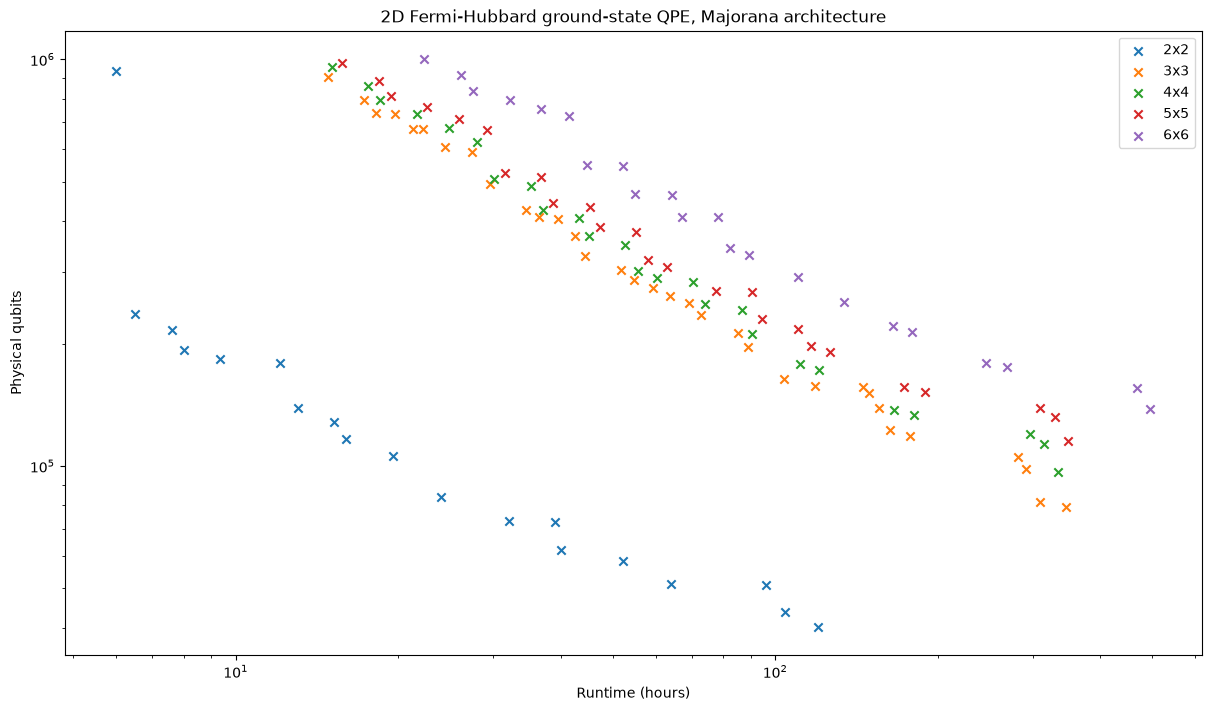

In [7]:
fig = plot_estimates(tables, runtime_unit="hours", figsize=(12, 7))
ax = fig.axes[0]
ax.set_title("2D Fermi-Hubbard ground-state QPE, Majorana architecture")
fig.set_layout_engine("constrained")
fig

## Extending the sweep

Two costs, neither of them the resource estimation, decide how far $L$ can go:

- the order-2 commutator bound is $O(n_{\mathrm{terms}}^{3})$ -- seconds at $L = 4$, minutes at $L = 6$, hours
  beyond $L = 10$. Switching `qpe_parameters` to `trotter_steps_naive` makes this cost linear at the price of a
  looser (larger) step count;
- compiling the controlled-$U^{2^{k}}$ ladder grows with the number of Pauli terms, roughly a minute at
  $L = 20$; past $L \approx 22$ the Jordan-Wigner mapper's 1024-qubit ceiling stops the sweep entirely.

Qubitization-based alternatives such as FOQCS or SOSSA would replace the product formula in
`hamiltonian_unitary_builder` and are worth revisiting for the same benchmark:

- [2601.18767v1] Practical block encodings of matrix polynomials that can also be trivially controlled
- [2602.05069v1] Near-frustration-free electronic structure Hamiltonian representations and lower bound certificates